In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

In [ ]:
df = df.head(100)

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              100 non-null    int64 
 1   Gender                  100 non-null    object
 2   Age                     100 non-null    int64 
 3   Annual Income (k$)      100 non-null    int64 
 4   Spending Score (1-100)  100 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 4.0+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,100.000000,100.000000,100.000000,100.000000
mean,50.500000,39.750000,39.560000,49.930000
std,29.011492,15.626561,14.212187,21.656294
min,1.000000,18.000000,15.000000,3.000000
25%,25.750000,24.750000,28.000000,41.000000
50%,50.500000,36.500000,41.000000,50.000000
75%,75.250000,50.250000,54.000000,60.000000
max,100.000000,70.000000,61.000000,99.000000


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

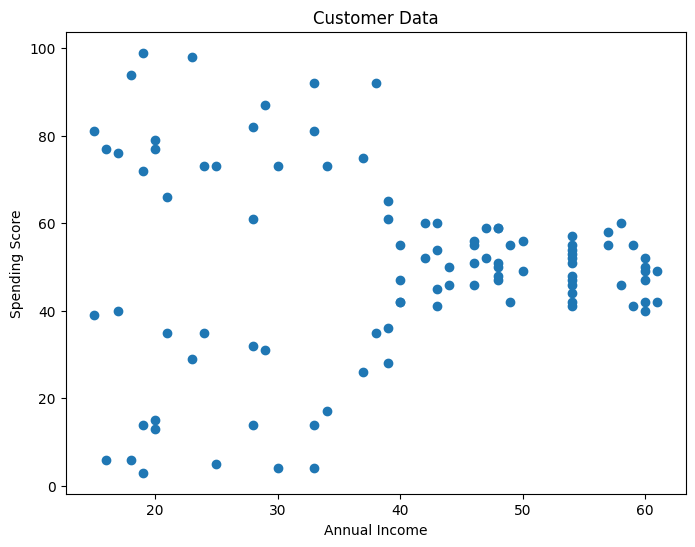

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

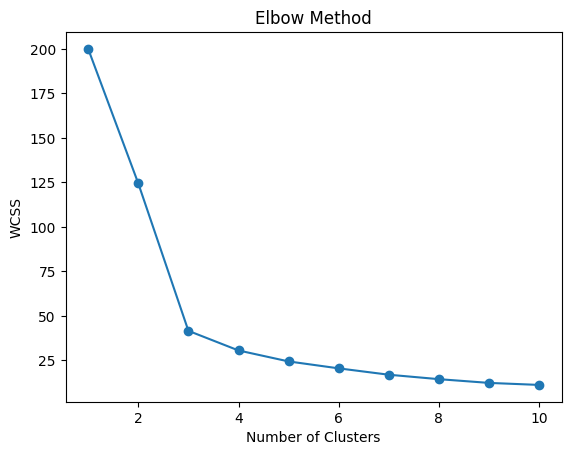

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

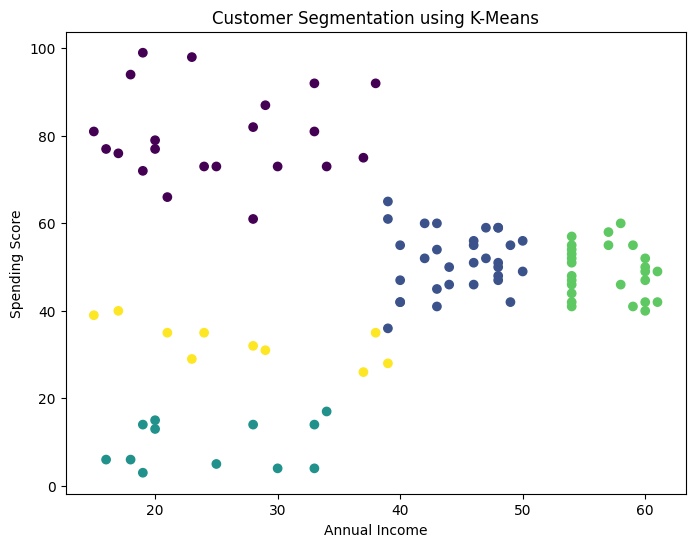

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.show()